# Columnas desde DXF

Lee `section_01.dxf`, reporta areas pequenas/no identificadas con geometria WKT y procesa una columna discretizada.

In [1]:
from pathlib import Path
import json
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "src" / "dynaengine").exists():
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

DATA_DIR = ROOT / "examples" / "data"
MATERIALS_PATH = DATA_DIR / "section_01_materials.json"
materials = json.loads(MATERIALS_PATH.read_text(encoding="utf-8"))
print(f"Proyecto: {ROOT}")
print(f"Materiales cargados: {len(materials)}")

import pandas as pd
import matplotlib.pyplot as plt
from dynaengine import (
    apply_material_aliases,
    extract_columns_from_dxf,
    filter_columns_with_unresolved_materials,
    prepare_column_configs,
    process_column_config,
    resolve_unidentified_materials_detailed,
)
from dynaengine.plots import plot_dxf_extraction, plot_raw_column, plot_discretized_column
from dynaengine.dxf import _generate_clean_polygons, _read_dxf_layers

Proyecto: C:\Users\joel.alarcon\Desktop\_code\prismo\external\DynaEngine
Materiales cargados: 6


In [2]:
dxf_path = DATA_DIR / "section_01.dxf"
x_positions_by_failure = {f"failure_{index}": [250.0, 480.0] for index in range(1, 8)}
failure_types = {name: "tipo_de_falla" for name in x_positions_by_failure}
small_area_scale = 0.01
material_aliases = {}
unidentified_actions = {}

extraction = extract_columns_from_dxf(
    dxf_path,
    x_positions=x_positions_by_failure,
    material_aliases=material_aliases,
    failure_types=failure_types,
    small_area_scale=small_area_scale,
)
print(f"Columnas extraidas: {len(extraction.columns)}")
print(f"Materiales en DXF: {extraction.material_names}")
print(f"Estratos no identificados: {extraction.unidentified_materials}")

Columnas extraidas: 2
Materiales en DXF: ['Estrato no identificado 1', 'Grava arcillosa', 'Grava arenosa', 'Grava pobremente gradada']
Estratos no identificados: ['Estrato no identificado 1']


In [3]:
area_notifications = pd.DataFrame(extraction.area_notifications)
area_notifications[[
    "notification_type",
    "material_name",
    "polygon_id",
    "area_m2",
    "area_ratio_to_total",
    "bounds",
    "representative_point",
    "geometry_wkt",
]] if not area_notifications.empty else area_notifications

,notification_type,material_name,polygon_id,area_m2,area_ratio_to_total,bounds,representative_point,geometry_wkt
0,[unidentified_material],Estrato no identificado 1,9,1792.27472,0.04343,"[403.59899, 4172.62551, 484.97031, 4214.91671]","[455.86255, 4200.2415]","POLYGON ((403.5989867524823 4172.625511705527,..."
1,[small_area_omitted],Material dique,7,334.17383,0.00810,"[301.34365, 4250.00012, 343.94842, 4264.9999]","[324.06206, 4256.84887]","POLYGON ((301.3436451849325 4250.0001153995, 3..."
2,[small_area_omitted],Material de poza,6,132.32591,0.00321,"[235.50702, 4226.38146, 261.6096, 4235.4989]","[248.94228, 4229.00009]","POLYGON ((235.5070205673631 4235.498897805883,..."
3,[small_area_omitted],Grava arenosa,10,3.48914,0.00008,"[301.61713, 4132.62551, 326.50229, 4142.59663]","[319.67445, 4137.64334]","POLYGON ((301.6171259280715 4132.625511693097,..."


In [4]:
resolution = resolve_unidentified_materials_detailed(
    materials,
    extraction.unidentified_materials,
    actions=unidentified_actions,
    material_aliases=material_aliases,
)
all_aliases = {**material_aliases, **resolution.aliases}
columns = apply_material_aliases(extraction.columns, all_aliases)
columns, omitted_columns = filter_columns_with_unresolved_materials(columns, resolution.unresolved)

print(f"Alias aplicados: {all_aliases}")
print(f"Columnas omitidas por estrato no resuelto: {omitted_columns}")
print(f"Columnas listas: {list(columns)}")

Alias aplicados: {}
Columnas omitidas por estrato no resuelto: []
Columnas listas: ['section_01-failure_3-x250p0', 'section_01-failure_7-x480p0']


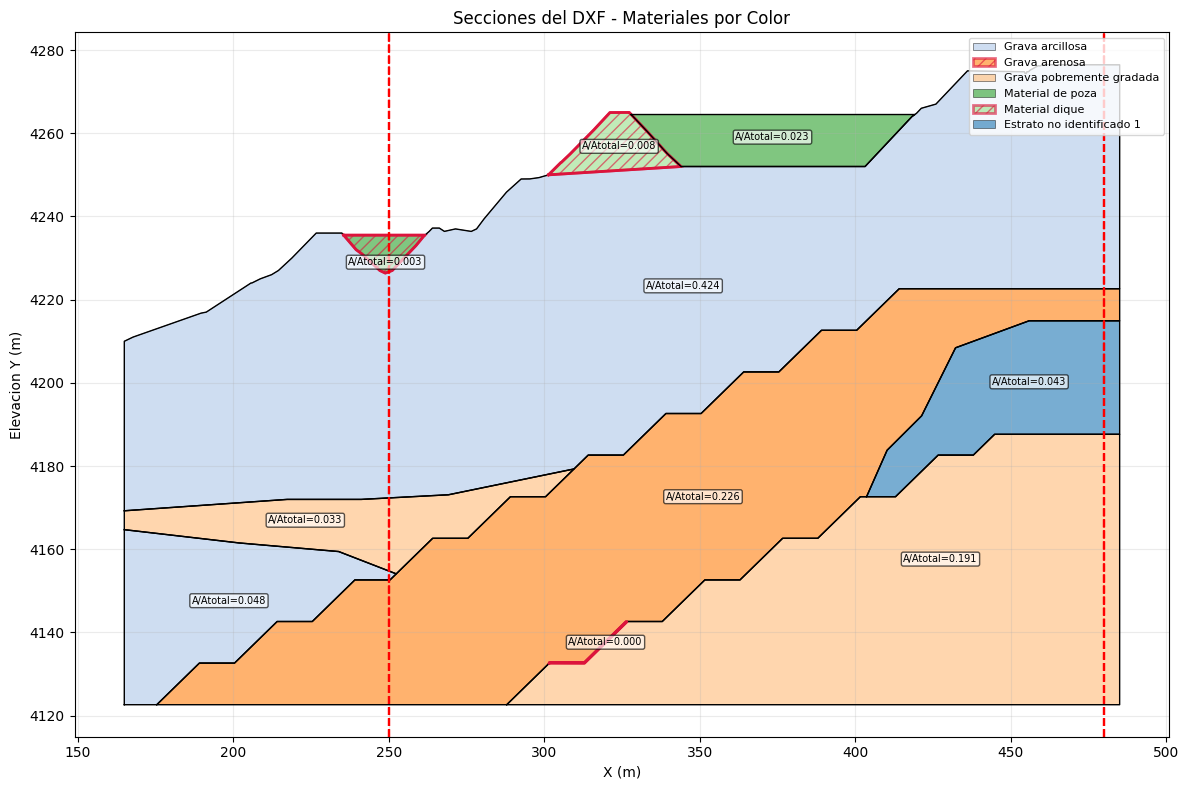

In [5]:
external, freatic, material, failure, text = _read_dxf_layers(dxf_path)
clean_polygons, total_area = _generate_clean_polygons(
    external,
    material,
    text,
    small_area_scale=small_area_scale,
)
fig, ax = plot_dxf_extraction(
    clean_polygons,
    x_positions=[x for xs in x_positions_by_failure.values() for x in xs],
    highlight_small_areas=True,
    small_area_scale=small_area_scale,
    annotate_areas=True,
)
plt.show()

In [6]:
configs = prepare_column_configs(columns, resolution.materials, target_frequency_hz=25)
first_name = next(iter(configs))
result = process_column_config(configs[first_name], calibrate=False)
print(first_name)
display(result.raw)
display(result.discretized.head())

section_01-failure_3-x250p0


,layer_id,column_name,material_name,top_m,bottom_m,center_depth_m,thickness_m,unit_weight_kn_m3,shear_velocity_m_s,sigma_v_center_kpa,gmax_kpa,tau_kpa,k0,failure_surface_name,failure_type,failure_height_m,failure_surface_depth_m,passes_failure_surface
0,1,section_01-failure_3-x250p0,Grava arcillosa,0.00000,63.17022,31.585110,63.17022,19.0,412.393911,600.117090,329388.992183,474.315399,0.7,failure_3,tipo_de_falla,10.23481,6.28905,True
1,2,section_01-failure_3-x250p0,Grava pobremente gradada,63.17022,80.72175,71.945985,17.55153,19.0,500.000000,990.211493,484199.796126,690.560178,0.5,failure_3,tipo_de_falla,10.23481,6.28905,False
2,3,section_01-failure_3-x250p0,Grava arcillosa,80.72175,82.87298,81.797365,2.15123,19.0,600.000000,1080.745675,697247.706422,854.190499,0.7,failure_3,tipo_de_falla,10.23481,6.28905,False
3,4,section_01-failure_3-x250p0,Grava arenosa,82.87298,112.87278,97.872880,29.99980,19.0,700.000000,1228.479658,949031.600408,1142.300256,1.0,failure_3,tipo_de_falla,10.23481,6.28905,False


,segment_id,source_layer_id,column_name,material_name,top_m,bottom_m,center_depth_m,thickness_m,unit_weight_kn_m3,shear_velocity_m_s,natural_frequency_hz,sigma_v_center_kpa,gmax_kpa,tau_kpa,k0,failure_surface_name,failure_type,failure_height_m,failure_surface_depth_m,passes_failure_surface
0,1,1,section_01-failure_3-x250p0,Grava arcillosa,0.000000,1.974069,0.987035,1.974069,19.0,200.0,25.32839,18.753659,77471.96738,14.822356,0.7,failure_3,tipo_de_falla,10.23481,6.28905,False
1,2,1,section_01-failure_3-x250p0,Grava arcillosa,1.974069,3.948139,2.961104,1.974069,19.0,200.0,25.32839,56.260977,77471.96738,44.467069,0.7,failure_3,tipo_de_falla,10.23481,6.28905,False
2,3,1,section_01-failure_3-x250p0,Grava arcillosa,3.948139,5.922208,4.935173,1.974069,19.0,200.0,25.32839,93.768295,77471.96738,74.111781,0.7,failure_3,tipo_de_falla,10.23481,6.28905,False
3,4,1,section_01-failure_3-x250p0,Grava arcillosa,5.922208,7.896278,6.909243,1.974069,19.0,200.0,25.32839,131.275613,77471.96738,103.756494,0.7,failure_3,tipo_de_falla,10.23481,6.28905,True
4,5,1,section_01-failure_3-x250p0,Grava arcillosa,7.896278,9.870347,8.883312,1.974069,19.0,200.0,25.32839,168.782932,77471.96738,133.401206,0.7,failure_3,tipo_de_falla,10.23481,6.28905,False


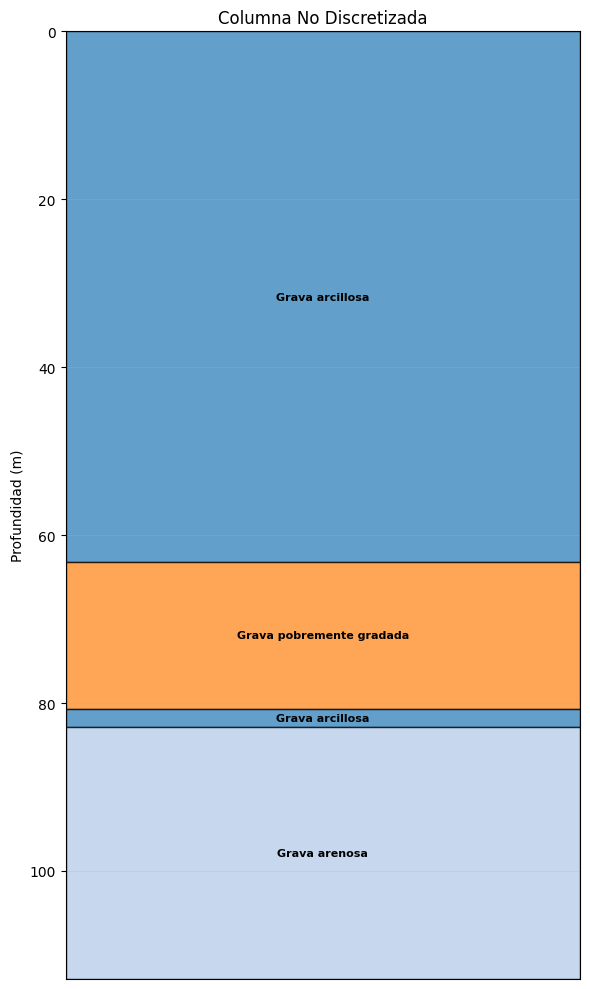

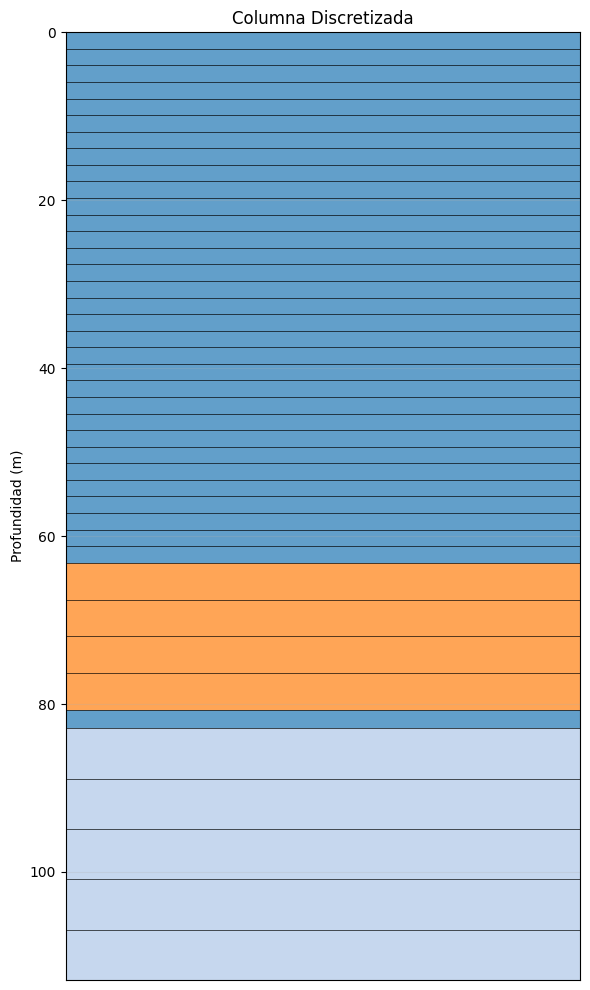

In [7]:
fig, ax = plot_raw_column(result.raw)
plt.show()
fig, ax = plot_discretized_column(result.discretized)
plt.show()